In [1]:
import pandas as pd
from datetime import date

btc = pd.read_csv(f"../data/bitcoin_{date.today()}.csv")

## Informacion del Dataset

Numero de filas y columnas:
- filas: 4178 Aprox
- Columnas: 6

### Columnas:

`Date` — La fecha de cada registro. Cada fila es un día de mercado.

`Open` (Apertura) — El precio de Bitcoin al comienzo del día. Es el primer precio al que se operó ese día.

`Close` (Cierre) — El precio de Bitcoin al final del día. Es el más importante y el que más se usa en análisis financiero. Cuando la gente dice "el precio de Bitcoin hoy" generalmente se refiere al cierre.

`High` (Máximo) — El precio más alto que alcanzó Bitcoin durante ese día.

`Low` (Mínimo) — El precio más bajo que alcanzó Bitcoin durante ese día.

`Volume` (Volumen) — La cantidad de dinero que se movió operando Bitcoin ese día, expresado en dólares. Un volumen alto significa que mucha gente compró y vendió ese día.


Ejemplo con un día real:


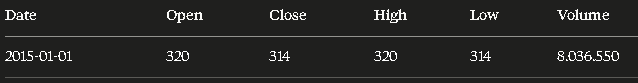

Ese día Bitcoin abrió en $320, cerró en $314, en algún momento del día llegó a $320 de máximo, bajó hasta $314 de mínimo, y se operaron $8 millones en total.

In [2]:
print(btc.head())

print("------------------------------------------")

print(btc.shape)

print("------------------------------------------")

print(btc.columns)

print("------------------------------------------")

print(btc.info())



        Price              Close                High                 Low  \
0      Ticker            BTC-USD             BTC-USD             BTC-USD   
1        Date                NaN                 NaN                 NaN   
2  2015-01-01  314.2489929199219  320.43499755859375  314.00299072265625   
3  2015-01-02  315.0320129394531   315.8389892578125  313.56500244140625   
4  2015-01-03  281.0820007324219   315.1499938964844   281.0820007324219   

                 Open    Volume  
0             BTC-USD   BTC-USD  
1                 NaN       NaN  
2  320.43499755859375   8036550  
3   314.0790100097656   7860650  
4  314.84600830078125  33054400  
------------------------------------------
(4180, 6)
------------------------------------------
Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 4180 entries, 0 to 4179
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtyp

## 2. Limpieza de datos

### 2.1 Problema inicial
Al cargar el CSV se detectaron dos filas iniciales generadas automáticamente 
por yfinance que no contenían datos reales:
- Fila 0: contenía el texto "Ticker" y "BTC-USD"
- Fila 1: contenía el texto "Date" y valores NaN

Además la columna de fechas tenía el nombre incorrecto "Price" 
y todas las columnas estaban en formato string (object).

### 2.2 Pasos realizados
1. Eliminación de las filas 0 y 1
2. Renombre de la columna "Price" a "Date"
3. Reset del índice para que arranque desde 0
4. Conversión de la columna Date a tipo datetime
5. Conversión de las columnas numéricas (Close, High, Low, Open, Volume) a tipo float

*Eliminacion de filas iniciales y correcion del nombre "Price" por "Date"*

In [3]:
btc = btc.drop([0, 1])
btc = btc.rename(columns={"Price":"Date"})
btc = btc.reset_index(drop=True)

btc.head()


,Date,Close,High,Low,Open,Volume
0,2015-01-01,314.2489929199219,320.43499755859375,314.00299072265625,320.43499755859375,8036550
1,2015-01-02,315.0320129394531,315.8389892578125,313.56500244140625,314.0790100097656,7860650
2,2015-01-03,281.0820007324219,315.1499938964844,281.0820007324219,314.84600830078125,33054400
3,2015-01-04,264.19500732421875,287.2300109863281,257.61199951171875,281.14599609375,55629100
4,2015-01-05,274.4739990234375,278.34100341796875,265.0840148925781,265.0840148925781,43962800


*Todas las columnas llegaron como object (texto) porque venían de un CSV con filas raras arriba. Hay que convertirlas a los tipos correctos:*

In [4]:
btc.dtypes

Date      str
Close     str
High      str
Low       str
Open      str
Volume    str
dtype: object

In [5]:
btc["Date"] = pd.to_datetime(btc["Date"])

columnas_numericas = ["Open", "High", "Low", "Close", "Volume"]
btc[columnas_numericas] = btc[columnas_numericas].astype(float)

btc.dtypes

Date      datetime64[us]
Close            float64
High             float64
Low              float64
Open             float64
Volume           float64
dtype: object

### 2.3 Verificación de calidad del dataset

Antes de continuar con el análisis se verificó la integridad del dataset
comprobando la ausencia de valores nulos y filas duplicadas, ya que estos
problemas pueden afectar los resultados del análisis.

*Verificacion de valores nulos*

In [6]:
btc.isnull().sum() 

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

*No hay valores nulos dentro del dataset*

*Verificacion de filas repetidas*

In [7]:
total_filas_duplicadas = btc.duplicated().sum()
print(f"Total de filas duplicadas: {total_filas_duplicadas}")

Total de filas duplicadas: 0


*No hay filas repetidas*

##### Guardado del nuevo Dataset limpio


In [8]:
btc.to_csv("../data/bitcoin_limpio.csv", index=False)
print("Dataset limpio guardado correctamente")

Dataset limpio guardado correctamente
